# Áreas de risco alimentar e vulnerabilidade social no Brasil

**Estudo ecológico municipal — sobreposição de critérios.**

Pergunta: onde coincidem IVS elevado, risco alimentar estimado elevado no
CadInsan e déficit de altura/estatura para idade (DAI) elevado no SISVAN?

IVS/IDHM: **2010**. Arquivo CadInsan e SISVAN: **2025**. SISVAN: crianças de
**0 a menos de 5 anos acompanhadas pelo sistema**. CadÚnico JSON: período e
unidade ainda não confirmados. A análise é exploratória e não estabelece
causalidade nem estima a prevalência de fome na população inteira.

**Como executar:** no Colab, abrir este `.ipynb` pelo menu **Arquivo → Abrir
notebook → Upload**, revisar os parâmetros abaixo e usar **Ambiente de
execução → Executar tudo**. As quatro bases e a malha de apoio estão
incorporadas; não é necessário fornecer outros arquivos ou credenciais.
A instalação de dependências pode exigir internet. As fontes embutidas
ficam preservadas; os resultados vão para uma pasta separada.

**Versão das quatro bases selecionadas:** commit `3391236`. O processamento
abaixo deriva indicadores analíticos e mantém também os valores do arquivo.

## 1. Parâmetros da análise

A regra principal exige **os três critérios simultaneamente**. Valores
maiores são desfavoráveis para IVS, CadInsan e DAI. IDHM baixo e DPI alto
contextualizam os resultados, sem exigir cinco critérios simultâneos.

P75 e mínimo de 100 avaliações são pontos de partida exploratórios, editáveis
e sem caráter oficial. O corte do DAI é calculado sobre municípios com o
denominador mínimo; IVS e CadInsan usam seus próprios municípios disponíveis.
Cada município tem o mesmo peso nos quantis; empates no corte são incluídos.
Por isso o grupo elevado pode conter mais de 25% dos municípios.

`com_PBF` é a coluna escolhida para o cenário inicial. `sem_PBF` entra na
sensibilidade. **A documentação específica do arquivo local precisa ser
confirmada**: os nomes não permitem interpretar os cenários como grupos
de beneficiários e não beneficiários. Resultados são provisórios enquanto
essa correspondência e a referência temporal do arquivo não forem validadas.

In [1]:
QUANTIL = 0.75
MINIMO_AVALIADOS = 100
CENARIO_CADINSAN = "com_PBF"  # opções: "com_PBF", "sem_PBF"
QUANTIS_SENSIBILIDADE = [0.75, 0.80]
MINIMOS_SENSIBILIDADE = [30, 50, 100]
CENARIOS_SENSIBILIDADE = ["com_PBF", "sem_PBF"]
GERAR_MAPAS = True
BAIXAR_RESULTADOS_NO_COLAB = False  # True solicita download do ZIP no final

# Somente preencha depois de conferir a documentação das fontes locais.
DEFINICOES_CADINSAN_CONFIRMADAS = False
CADUNICO_UNIDADE_CONFIRMADA = ""
CADUNICO_PERIODO_CONFIRMADO = ""
CODIGO_ANALISE_SHA256 = "a2194d25ebeb160bdf55f6aa5c25d644ffb0467b6178ec7ae4f0a37f583283c6"

## 2. Ambiente e recuperação das bases incorporadas

Esta célula confere bibliotecas e restaura o pacote autocontido em uma pasta
da sessão. A próxima célula contém o pacote compactado e pode ficar recolhida.
Os hashes das quatro bases são conferidos antes do processamento. A malha
tem hash próprio. Não há nova consulta ao SISVAN ou às fontes sociais.

In [2]:
import importlib.util
import subprocess
import sys
from pathlib import Path

packages = {"pandas": "pandas>=2.2,<4", "numpy": "numpy>=1.26,<3",
            "matplotlib": "matplotlib>=3.8,<4", "scipy": "scipy>=1.11,<2"}
missing = [requirement for module, requirement in packages.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import hashlib
import io
import json
import zipfile
import base64
import platform
import shutil
from datetime import datetime, timezone
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
from IPython.display import display, Markdown

PASTA_EXECUCAO = Path.cwd() / "resultados_sobreposicao"
PASTA_DADOS = PASTA_EXECUCAO / "entradas"
PASTA_SAIDA = PASTA_EXECUCAO / "resultados"
PASTA_FIGURAS = PASTA_SAIDA / "figuras"
PASTA_SAIDA.mkdir(parents=True, exist_ok=True)
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
print("Resultados:", PASTA_SAIDA)

Resultados: /tmp/risco-notebook-execucao-diyd4nhx/resultados_sobreposicao/resultados


In [3]:
# @title Bases e malha incorporadas — executar sem editar
PACOTE_BASE64 = "..."
with zipfile.ZipFile(io.BytesIO(base64.b64decode(PACOTE_BASE64))) as pacote:
    for membro in pacote.infolist():
        destino = (PASTA_DADOS / membro.filename).resolve()
        if not destino.is_relative_to(PASTA_DADOS.resolve()):
            raise ValueError("Caminho inválido no pacote de dados")
    pacote.extractall(PASTA_DADOS)
print("Pacote recuperado. As quatro bases mantêm seus bytes originais.")

Pacote recuperado. As quatro bases mantêm seus bytes originais.


## 3. Funções reproduzíveis de leitura e análise

O código abaixo é incorporado de `scripts/analise_sobreposicao.py`. Ele
converte números somente em memória, valida categorias e denominadores,
realiza junções externas `one_to_one` por prefixos únicos e calcula as flags
com valores ausentes quando a classificação não é possível. Pode ser
expandido para auditoria; as células seguintes mostram a execução.

In [4]:
# @title Funções de análise — executar sem editar
"""Análise municipal exploratória usada pelo notebook autocontido do Colab."""

from __future__ import annotations

import hashlib
import json
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd


DATA_FILES = {
    "ivs_idhm": "ivs_idhm/atlasivs_municipios_2010.csv",
    "cadunico": "cadunico/municipios-cadunico.json",
    "cadinsan": "cadinsan/CADINSAN_2025_dados_municipais.csv",
    "sisvan": "sisvan/indicadores_altura_peso_idade_menores_5_2025.csv",
}
GROUP_COLORS = {
    "Convergência dos três critérios": "#9e1b32",
    "IVS e CadInsan elevados, DAI abaixo do corte": "#e89c38",
    "DAI elevado sem convergência social-alimentar": "#377eb8",
    "Outras combinações": "#d7e4df",
    "Informação insuficiente": "#b9b9b9",
}
UF_REGIONS = {
    "11": ("RO", "Norte"), "12": ("AC", "Norte"),
    "13": ("AM", "Norte"), "14": ("RR", "Norte"),
    "15": ("PA", "Norte"), "16": ("AP", "Norte"),
    "17": ("TO", "Norte"), "21": ("MA", "Nordeste"),
    "22": ("PI", "Nordeste"), "23": ("CE", "Nordeste"),
    "24": ("RN", "Nordeste"), "25": ("PB", "Nordeste"),
    "26": ("PE", "Nordeste"), "27": ("AL", "Nordeste"),
    "28": ("SE", "Nordeste"), "29": ("BA", "Nordeste"),
    "31": ("MG", "Sudeste"), "32": ("ES", "Sudeste"),
    "33": ("RJ", "Sudeste"), "35": ("SP", "Sudeste"),
    "41": ("PR", "Sul"), "42": ("SC", "Sul"), "43": ("RS", "Sul"),
    "50": ("MS", "Centro-Oeste"), "51": ("MT", "Centro-Oeste"),
    "52": ("GO", "Centro-Oeste"), "53": ("DF", "Centro-Oeste"),
}


def verify_hashes(directory):
    directory = Path(directory)
    records = []
    for line in (directory / "SHA256SUMS").read_text().splitlines():
        if not line.strip():
            continue
        expected, relative = line.split(maxsplit=1)
        relative = relative.lstrip("*")
        path = directory / relative
        actual = hashlib.sha256(path.read_bytes()).hexdigest()
        if actual != expected:
            raise ValueError(f"Integridade inválida: {relative}")
        records.append({"arquivo": relative, "sha256": actual, "integridade": "OK"})
    if {r["arquivo"] for r in records} != set(DATA_FILES.values()):
        raise ValueError("O manifesto deve identificar exatamente as quatro bases.")
    return pd.DataFrame(records)


def numeric(values, label):
    """Lê ponto/vírgula decimal e %, sem converter ausência em zero."""
    clean = values.astype("string").str.strip()
    clean = clean.str.replace("%", "", regex=False).str.replace(",", ".", regex=False)
    present = clean.notna() & clean.ne("")
    result = pd.to_numeric(clean.mask(~present), errors="coerce").astype(float)
    invalid = present & result.isna()
    if invalid.any():
        raise ValueError(f"Valores não numéricos em {label}: {values[invalid].head().tolist()}")
    if not np.isfinite(result.dropna()).all():
        raise ValueError(f"Valores infinitos em {label}")
    return result


def codes(values, length, source):
    result = values.astype("string").str.strip()
    if not result.str.fullmatch(rf"\d{{{length}}}").fillna(False).all():
        raise ValueError(f"{source}: códigos devem ter {length} dígitos.")
    if result.duplicated().any():
        raise ValueError(f"{source}: código municipal duplicado.")
    return result


def check_range(values, low, high, label):
    if not values.dropna().between(low, high).all():
        raise ValueError(f"{label}: valores fora de [{low}, {high}].")


def read_sources(directory):
    directory = Path(directory)
    hashes = verify_hashes(directory)
    sources = {}
    for key, relative in DATA_FILES.items():
        if key == "cadunico":
            def unique_keys(pairs):
                result = {}
                for code, value in pairs:
                    if code in result:
                        raise ValueError(f"CadÚnico: chave JSON duplicada: {code}")
                    result[code] = value
                return result
            data = json.loads((directory / relative).read_text(encoding="utf-8"),
                              object_pairs_hook=unique_keys)
            sources[key] = pd.DataFrame({"codigo_ibge_7": list(data),
                                         "cadunico_valor_original": list(data.values())})
        else:
            sources[key] = pd.read_csv(directory / relative, dtype="string",
                                      encoding="utf-8-sig", keep_default_na=False)
    return sources, hashes


def prepare_base(directory):
    """Normaliza cópias em memória e integra por prefixos únicos, com auditoria."""
    sources, hashes = read_sources(directory)
    tables = {}
    ivs = sources["ivs_idhm"]
    tables["ivs_idhm"] = pd.DataFrame({
        "codigo_ivs_original": codes(ivs["municipio"], 7, "IVS/IDHM"),
        "municipio_ivs": ivs["nome_municipio_uf"],
    })
    for column in ivs.columns:
        if column not in ("municipio", "nome_municipio_uf"):
            tables["ivs_idhm"][column] = numeric(ivs[column], column)
            check_range(tables["ivs_idhm"][column], 0, 1, column)

    cad = sources["cadunico"]
    tables["cadunico"] = pd.DataFrame({
        "codigo_cadunico_original": codes(cad["codigo_ibge_7"], 7, "CadÚnico"),
        "cadunico_valor_original": numeric(cad["cadunico_valor_original"], "CadÚnico"),
    })
    ci = sources["cadinsan"]
    tables["cadinsan"] = pd.DataFrame({
        "codigo_cadinsan_original": codes(ci["Cod_IBGE"], 7, "CadInsan"),
        "municipio_cadinsan": ci["Município"],
    })
    renames = {
        "Cadastros_Cadunico": "cadastros_cadunico_cadinsan",
        "Cadinsan_absoluto_com_PBF": "cadinsan_n_com_PBF",
        "Cadinsan_absoluto_sem_PBF": "cadinsan_n_sem_PBF",
        "Cadinsan_proporcional_com_PBF": "cadinsan_pct_com_PBF",
        "Cadinsan_proporcional_sem_PBF": "cadinsan_pct_sem_PBF",
    }
    for original, new in renames.items():
        tables["cadinsan"][new] = numeric(ci[original], original)
    sv = sources["sisvan"]
    if not sv["Ano"].eq("2025").all() or not sv["Faixa etária"].eq("0 a < 5 anos").all():
        raise ValueError("SISVAN fora do recorte previsto: 2025, menores de 5 anos.")
    if not sv["Fase da vida"].eq("CRIANÇA").all():
        raise ValueError("SISVAN contém outra fase da vida.")
    tables["sisvan"] = pd.DataFrame({
        "codigo_sisvan_original": codes(sv["Código IBGE"], 6, "SISVAN"),
        "municipio_sisvan": sv["Município"], "uf_sisvan": sv["UF"],
        "ano_sisvan": numeric(sv["Ano"], "Ano"),
    })
    counts = {
        "Altura Muito Baixa para a Idade - Quantidade": "altura_muito_baixa_n",
        "Altura Baixa para a Idade - Quantidade": "altura_baixa_n",
        "Altura Adequada para a Idade - Quantidade": "altura_adequada_n",
        "Total avaliado - Altura X Idade": "avaliados_altura",
        "Peso Muito Baixo para a Idade - Quantidade": "peso_muito_baixo_n",
        "Peso Baixo para a Idade - Quantidade": "peso_baixo_n",
        "Peso Adequado ou Eutrófico - Quantidade": "peso_adequado_n",
        "Peso Elevado para a Idade - Quantidade": "peso_elevado_n",
        "Total avaliado - Peso X Idade": "avaliados_peso",
        "Déficit de estatura - Quantidade": "dai_n_arquivo",
        "Déficit de peso para idade - Quantidade": "dpi_n_arquivo",
        "Déficit de estatura - %": "dai_pct_arquivo",
        "Déficit de peso para idade - %": "dpi_pct_arquivo",
    }
    for original, new in counts.items():
        tables["sisvan"][new] = numeric(sv[original], original)
    for source, table in tables.items():
        original = next(c for c in table if c.startswith("codigo_"))
        table["codigo_ibge_6"] = table[original].str[:6]
        if table["codigo_ibge_6"].duplicated().any():
            raise ValueError(f"{source}: prefixos municipais não são únicos.")
        table[f"tem_{source}"] = True

    # União externa: ausência de uma fonte não elimina o território das demais.
    base = tables["sisvan"]
    for source in ("ivs_idhm", "cadunico", "cadinsan"):
        base = base.merge(tables[source], on="codigo_ibge_6", how="outer",
                          validate="one_to_one")
    for source in tables:
        base[f"tem_{source}"] = base[f"tem_{source}"].fillna(False).astype(bool)
    original_7 = ["codigo_cadinsan_original", "codigo_ivs_original", "codigo_cadunico_original"]
    base["codigo_ibge_7"] = base[original_7].bfill(axis=1).iloc[:, 0]
    for column in original_7:
        conflict = base[column].notna() & base["codigo_ibge_7"].ne(base[column])
        if conflict.any():
            raise ValueError("Conflito entre códigos de sete dígitos das fontes.")
    # O código de 7 dígitos desconhecido permanece ausente; nunca inventar DV.
    base["municipio"] = base[["municipio_sisvan", "municipio_cadinsan", "municipio_ivs"]].bfill(axis=1).iloc[:, 0]
    base["uf"] = base["codigo_ibge_6"].str[:2].map(lambda c: UF_REGIONS[c][0])
    base["regiao"] = base["codigo_ibge_6"].str[:2].map(lambda c: UF_REGIONS[c][1])
    sv_rows = base["tem_sisvan"]
    if base.loc[sv_rows, "uf"].ne(base.loc[sv_rows, "uf_sisvan"]).any():
        raise ValueError("UF SISVAN incompatível com o prefixo municipal.")

    nonnegative = [c for c in base if c.endswith("_n") or c.startswith("avaliados_")]
    nonnegative += ["cadunico_valor_original", "cadastros_cadunico_cadinsan",
                    "cadinsan_n_com_PBF", "cadinsan_n_sem_PBF"]
    for column in nonnegative:
        values = base[column].dropna()
        if (values < 0).any() or not np.isclose(values % 1, 0).all():
            raise ValueError(f"{column}: contagem negativa ou não inteira.")
    for prefix, parts, total in (
        ("dai", ["altura_muito_baixa_n", "altura_baixa_n", "altura_adequada_n"], "avaliados_altura"),
        ("dpi", ["peso_muito_baixo_n", "peso_baixo_n", "peso_adequado_n", "peso_elevado_n"], "avaliados_peso"),
    ):
        component_total = base[parts].sum(axis=1, min_count=len(parts))
        if not np.allclose(component_total[sv_rows], base.loc[sv_rows, total], equal_nan=False):
            raise ValueError(f"Soma das categorias incompatível com {total}.")
        base[f"{prefix}_n"] = base[parts[:2]].sum(axis=1, min_count=2)
        if not np.allclose(base.loc[sv_rows, f"{prefix}_n"], base.loc[sv_rows, f"{prefix}_n_arquivo"]):
            raise ValueError(f"Numerador {prefix} incompatível com o CSV.")
        base[f"{prefix}_pct"] = base[f"{prefix}_n"].div(base[total].where(base[total] > 0)) * 100
        valid = base[total] > 0
        if not np.allclose(base.loc[valid, f"{prefix}_pct"],
                           base.loc[valid, f"{prefix}_pct_arquivo"], atol=0.011):
            raise ValueError(f"Percentual {prefix} incompatível com a fórmula.")
        check_range(base[f"{prefix}_pct"], 0, 100, prefix)
    for scenario in ("com_PBF", "sem_PBF"):
        check_range(base[f"cadinsan_pct_{scenario}"], 0, 100, "CadInsan")
        denominator = base["cadastros_cadunico_cadinsan"]
        absolute = base[f"cadinsan_n_{scenario}"]
        if (absolute > denominator).fillna(False).any():
            raise ValueError("CadInsan absoluto excede o total de cadastros informado.")
        calculated = absolute.div(denominator.where(denominator > 0)) * 100
        reported = base[f"cadinsan_pct_{scenario}"]
        complete = calculated.notna() & reported.notna()
        if not np.allclose(calculated[complete], reported[complete], atol=0.11):
            raise ValueError("Percentual CadInsan diverge da razão no arquivo.")
    audit = pd.DataFrame([
        {"fonte": source, "registros_origem": len(table),
         "municipios_na_uniao": len(base), "correspondencias_sisvan": int((base[f"tem_{source}"] & sv_rows).sum()),
         "sisvan_sem_fonte": int((sv_rows & ~base[f"tem_{source}"]).sum()),
         "fonte_sem_sisvan": int((~sv_rows & base[f"tem_{source}"]).sum())}
        for source, table in tables.items()
    ])
    base = base.sort_values("codigo_ibge_6").reset_index(drop=True)
    return base, audit, hashes


def classify(base, quantile=0.75, min_evaluated=100, scenario="com_PBF"):
    """Cortes nacionais por indicador; DAI usa apenas denominadores elegíveis."""
    if not 0 < quantile < 1 or not isinstance(min_evaluated, int) or min_evaluated < 1:
        raise ValueError("Quantil deve estar entre 0 e 1 e o mínimo deve ser inteiro positivo.")
    if scenario not in ("com_PBF", "sem_PBF"):
        raise ValueError("Cenário deve ser com_PBF ou sem_PBF.")
    result = base.copy()
    result["cadinsan_pct"] = result[f"cadinsan_pct_{scenario}"]
    result["cadinsan_n"] = result[f"cadinsan_n_{scenario}"]
    specs = [
        ("ivs", "ivs", True, pd.Series(True, index=result.index)),
        ("cadinsan", "cadinsan_pct", True, result["cadastros_cadunico_cadinsan"] > 0),
        ("dai", "dai_pct", True, result["avaliados_altura"] >= min_evaluated),
        ("idhm", "idhm", False, pd.Series(True, index=result.index)),
        ("dpi", "dpi_pct", True, result["avaliados_peso"] >= min_evaluated),
    ]
    thresholds = []
    for label, column, high, eligible in specs:
        valid = eligible & result[column].notna()
        if not valid.any():
            raise ValueError(f"Nenhum município elegível para {label}.")
        cutoff = result.loc[valid, column].quantile(quantile if high else 1 - quantile)
        flag = pd.Series(pd.NA, index=result.index, dtype="boolean")
        flag.loc[valid] = (result.loc[valid, column] >= cutoff if high
                           else result.loc[valid, column] <= cutoff)
        result[f"criterio_{label}"] = flag
        thresholds.append({"indicador": label, "corte": float(cutoff),
                           "operador": ">=" if high else "<=",
                           "municipios_referencia": int(valid.sum()),
                           "municipios_no_criterio": int(flag.fillna(False).sum()),
                           "percentil": quantile * 100 if high else (1 - quantile) * 100})
    primary = ["criterio_ivs", "criterio_cadinsan", "criterio_dai"]
    result["elegivel_principal"] = result[primary].notna().all(axis=1)
    result["prioritario"] = result[primary].all(axis=1).where(result["elegivel_principal"]).astype("boolean")
    result["numero_criterios_primarios"] = result[primary].sum(axis=1).where(result["elegivel_principal"]).astype("Int64")
    social = (result["criterio_ivs"] & result["criterio_cadinsan"]).fillna(False)
    height = result["criterio_dai"].fillna(False)
    eligible = result["elegivel_principal"]
    groups = list(GROUP_COLORS)
    result["perfil"] = groups[4]
    result.loc[eligible, "perfil"] = groups[3]
    result.loc[eligible & height & ~social, "perfil"] = groups[2]
    result.loc[eligible & social & ~height, "perfil"] = groups[1]
    result.loc[eligible & social & height, "perfil"] = groups[0]
    reasons = []
    for row in result.itertuples():
        missing = []
        if pd.isna(row.ivs): missing.append("IVS ausente")
        if pd.isna(row.cadinsan_pct) or not row.cadastros_cadunico_cadinsan > 0:
            missing.append("CadInsan ausente ou denominador inválido")
        if pd.isna(row.avaliados_altura) or row.avaliados_altura <= 0:
            missing.append("sem avaliações de altura")
        elif row.avaliados_altura < min_evaluated:
            missing.append(f"menos de {min_evaluated} avaliações de altura")
        elif pd.isna(row.dai_pct): missing.append("DAI ausente")
        reasons.append("; ".join(missing))
    result["motivo_nao_classificacao"] = reasons
    result["cenario_cadinsan"] = scenario
    result["quantil_classificacao"] = quantile
    result["minimo_avaliados"] = min_evaluated
    return result, pd.DataFrame(thresholds)


def sensitivity(base, reference, quantiles=(0.75, 0.80), minima=(30, 50, 100),
                scenarios=("com_PBF", "sem_PBF")):
    reference_set = set(reference.loc[reference["prioritario"].fillna(False), "codigo_ibge_6"])
    records, selections = [], []
    for scenario, quantile, minimum in product(scenarios, quantiles, minima):
        result, _ = classify(base, quantile, minimum, scenario)
        selected = set(result.loc[result["prioritario"].fillna(False), "codigo_ibge_6"])
        union = reference_set | selected
        records.append({"cenario": scenario, "quantil": quantile, "minimo_avaliados": minimum,
                        "elegiveis": int(result["elegivel_principal"].sum()),
                        "prioritarios": len(selected), "coincidentes_principal": len(reference_set & selected),
                        "jaccard_principal": len(reference_set & selected) / len(union) if union else 1.0})
        selections.append(pd.DataFrame({"codigo_ibge_6": result["codigo_ibge_6"],
                                        "elegivel": result["elegivel_principal"],
                                        "selecionado": result["prioritario"].fillna(False).astype(int)}))
    all_selections = pd.concat(selections, ignore_index=True)
    stability = all_selections.groupby("codigo_ibge_6").agg(
        cenarios_elegiveis=("elegivel", "sum"), cenarios_selecionado=("selecionado", "sum"))
    stability["cenarios_testados"] = len(records)
    stability["fracao_cenarios_selecionado"] = stability["cenarios_selecionado"] / len(records)
    return pd.DataFrame(records), stability.reset_index()


def regional_summary(result):
    records = []
    for region, table in result.groupby("regiao", sort=True):
        record = {"regiao": region, "municipios": len(table),
                  "elegiveis": int(table["elegivel_principal"].sum()),
                  "prioritarios": int(table["prioritario"].fillna(False).sum())}
        record["pct_prioritarios_entre_elegiveis"] = (
            record["prioritarios"] / record["elegiveis"] * 100 if record["elegiveis"] else np.nan)
        for label, total in (("dai", "avaliados_altura"), ("dpi", "avaliados_peso")):
            valid = table[total].gt(0) & table[f"{label}_n"].notna()
            denominator = table.loc[valid, total].sum()
            record[f"{label}_n"] = table.loc[valid, f"{label}_n"].sum()
            record[total] = denominator
            record[f"{label}_pct_agregado"] = (
                record[f"{label}_n"] / denominator * 100 if denominator else np.nan)
        records.append(record)
    return pd.DataFrame(records)


def dictionary():
    rows = [
        ("codigo_ibge_6", "Chave analítica por prefixo único", "texto", "Fontes; origem preservada", "Não implica harmonização histórica completa"),
        ("codigo_ibge_7", "Código informado nas fontes sociais", "texto", "IVS/CadÚnico/CadInsan", "Ausente quando nenhuma fonte social fornece o código"),
        ("ivs", "Índice de Vulnerabilidade Social", "0–1", "IVS, 2010", "Maior: maior vulnerabilidade"),
        ("idhm", "Índice de Desenvolvimento Humano Municipal", "0–1", "IDHM, 2010", "Menor: menor desenvolvimento; contextual"),
        ("cadunico_valor_original", "Valor municipal do JSON", "não confirmada", "CadÚnico, período não informado", "Unidade e período pendentes; não integra a regra"),
        ("cadastros_cadunico_cadinsan", "Cadastros_Cadunico no CSV", "conforme arquivo", "CADINSAN_2025", "Não equivale automaticamente ao JSON"),
        ("cadinsan_pct", "Percentual do cenário selecionado", "%", "CADINSAN_2025", "com_PBF/sem_PBF são cenários; documentação local pendente"),
        ("cadinsan_n", "Quantidade do cenário selecionado", "conforme arquivo", "CADINSAN_2025", "Dimensão absoluta; não soma com SISVAN"),
        ("dai_n", "Altura muito baixa + altura baixa", "registros avaliados", "SISVAN, 2025", "Numerador recalculado"),
        ("dai_pct", "100 × dai_n / avaliados_altura", "%", "SISVAN, 2025", "Sem arredondamento; denominador zero gera NaN"),
        ("dpi_n", "Peso muito baixo + peso baixo", "registros avaliados", "SISVAN, 2025", "Indicador complementar"),
        ("dpi_pct", "100 × dpi_n / avaliados_peso", "%", "SISVAN, 2025", "Não somar com DAI"),
        ("avaliados_altura", "Total avaliado em Altura X Idade", "registros avaliados", "SISVAN, 2025", "Não é medida de cobertura populacional"),
        ("avaliados_peso", "Total avaliado em Peso X Idade", "registros avaliados", "SISVAN, 2025", "Denominador específico de DPI"),
        ("criterio_*", "Flag relativa ao corte nacional", "booleano anulável", "Análise derivada", "Ausente quando indicador não é elegível"),
        ("prioritario", "Coincidência de IVS, CadInsan e DAI elevados", "booleano anulável", "Análise derivada", "Ausente para informação insuficiente"),
        ("perfil", "Grupo exploratório de sobreposição", "categoria", "Análise derivada", "Não é classificação oficial"),
        ("fracao_cenarios_selecionado", "Fração das especificações que selecionam o município", "0–1", "Sensibilidade", "Não é probabilidade ou intervalo de confiança"),
    ]
    return pd.DataFrame(rows, columns=["variavel", "definicao", "unidade", "fonte_periodo", "observacao"])


def figure_style():
    import matplotlib.pyplot as plt
    plt.rcParams.update({"font.size": 10, "axes.spines.top": False,
                         "axes.spines.right": False, "figure.dpi": 110,
                         "savefig.dpi": 180})


def save_figure(fig, output, name):
    output = Path(output)
    output.mkdir(parents=True, exist_ok=True)
    fig.savefig(output / f"{name}.png", bbox_inches="tight")
    fig.savefig(output / f"{name}.svg", bbox_inches="tight")


def distribution_figure(result, output):
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    columns = [("ivs", "IVS — 2010"), ("idhm", "IDHM — 2010"),
               ("cadinsan_pct", "CadInsan (%) — cenário selecionado"),
               ("dai_pct", "DAI (%) — todos com avaliações"),
               ("dpi_pct", "DPI (%) — todos com avaliações"),
               ("avaliados_altura", "Avaliações de altura — escala log")]
    for ax, (column, title) in zip(axes.flat, columns):
        values = result[column].dropna()
        if column == "avaliados_altura":
            values = np.log10(values[values > 0])
            ax.set_xlabel("log10(total avaliado)")
        ax.hist(values, bins=35, color="#327c81", edgecolor="white", linewidth=0.4)
        ax.set_title(title)
        ax.set_ylabel("Municípios")
    fig.tight_layout()
    save_figure(fig, output, "01_distribuicoes")
    return fig


def association_figure(result, thresholds, output):
    import matplotlib.pyplot as plt
    cuts = thresholds.set_index("indicador")["corte"]
    valid = result[result["elegivel_principal"]]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    chosen = valid["prioritario"].fillna(False).to_numpy(dtype=bool)
    for ax, (column, label, criterion) in zip(axes, [
        ("ivs", "IVS (2010)", "ivs"), ("idhm", "IDHM (2010)", "idhm"),
        ("cadinsan_pct", "CadInsan (%)", "cadinsan")]):
        ax.scatter(valid[column], valid["dai_pct"], s=8, alpha=0.25, color="#327c81")
        ax.scatter(valid.loc[chosen, column], valid.loc[chosen, "dai_pct"],
                   s=13, alpha=0.7, color=GROUP_COLORS[list(GROUP_COLORS)[0]])
        ax.axhline(cuts["dai"], color="#777777", linestyle="--", linewidth=1)
        ax.axvline(cuts[criterion], color="#777777", linestyle="--", linewidth=1)
        ax.set(xlabel=label, ylabel="DAI (%)", title=f"{label} × DAI")
    fig.suptitle("Municípios elegíveis; vermelho = convergência dos três critérios")
    fig.tight_layout()
    save_figure(fig, output, "02_associacoes")
    return fig


def correlation_figure(result, output, minimum=100):
    import matplotlib.pyplot as plt
    cols = ["ivs", "idhm", "cadinsan_pct", "dai_pct", "dpi_pct"]
    data = result[cols].copy()
    data.loc[result["avaliados_altura"] < minimum, "dai_pct"] = np.nan
    data.loc[result["avaliados_peso"] < minimum, "dpi_pct"] = np.nan
    corr = data.corr(method="spearman", min_periods=3)
    pair_counts = data.notna().astype(int).T @ data.notna().astype(int)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(cols)), ["IVS", "IDHM", "CadInsan", "DAI", "DPI"])
    ax.set_yticks(range(len(cols)), ["IVS", "IDHM", "CadInsan", "DAI", "DPI"])
    for i in range(len(cols)):
        for j in range(len(cols)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}\nn={pair_counts.iloc[i, j]}",
                    ha="center", va="center", fontsize=9,
                    color="white" if abs(corr.iloc[i, j]) > 0.65 else "black")
    ax.set_title("Correlação de Spearman; pares disponíveis por comparação")
    fig.colorbar(im, ax=ax, shrink=0.8)
    fig.tight_layout()
    save_figure(fig, output, "03_correlacoes")
    return fig, corr, pair_counts


def sensitivity_figure(table, output):
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(11, 4.5))
    labels = [f"{r.cenario}\nP{r.quantil * 100:.0f} / n≥{r.minimo_avaliados}" for r in table.itertuples()]
    ax.bar(range(len(table)), table["prioritarios"], color="#327c81")
    ax.set_xticks(range(len(table)), labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Municípios selecionados")
    ax.set_title("Sensibilidade da seleção aos cortes, denominadores e cenários")
    fig.tight_layout()
    save_figure(fig, output, "04_sensibilidade")
    return fig


def geometry_audit(geojson, base):
    features = geojson["features"]
    codes_7 = pd.Series([str(f["properties"]["codarea"]) for f in features], dtype="string")
    codes(codes_7, 7, "Malha IBGE")
    prefixes = codes_7.str[:6]
    if prefixes.duplicated().any():
        raise ValueError("Malha com prefixos municipais duplicados.")
    existing = dict(zip(prefixes, codes_7))
    known = base["codigo_ibge_7"].notna()
    for row in base.loc[known].itertuples():
        if row.codigo_ibge_6 in existing and existing[row.codigo_ibge_6] != row.codigo_ibge_7:
            raise ValueError("Conflito de código municipal entre malha e bases sociais.")
    return pd.DataFrame({"codigo_ibge_6": base["codigo_ibge_6"],
                         "codigo_ibge_7_malha": base["codigo_ibge_6"].map(existing),
                         "tem_geometria": base["codigo_ibge_6"].isin(existing)})


def map_figure(geojson, result, column, title, output, filename, categories=None):
    """Mapa ilustrativo em coordenadas geográficas; anéis interiores preservados."""
    import matplotlib.pyplot as plt
    from matplotlib.collections import PatchCollection
    from matplotlib.colors import Normalize
    from matplotlib.path import Path as MplPath
    from matplotlib.patches import Patch, PathPatch
    lookup = result.set_index("codigo_ibge_6")[column].to_dict()
    patches, values, colors = [], [], []
    for feature in geojson["features"]:
        geometry = feature["geometry"]
        polygons = ([geometry["coordinates"]] if geometry["type"] == "Polygon"
                    else geometry["coordinates"])
        value = lookup.get(str(feature["properties"]["codarea"])[:6], np.nan)
        for polygon in polygons:
            vertices, commands = [], []
            for ring in polygon:
                coordinates = np.asarray(ring, dtype=float)[:, :2]
                if len(coordinates) < 4:
                    continue
                vertices.extend(coordinates)
                commands.extend([MplPath.MOVETO] + [MplPath.LINETO] * (len(coordinates) - 2) + [MplPath.CLOSEPOLY])
            if vertices:
                patches.append(PathPatch(MplPath(vertices, commands)))
                if categories is not None:
                    colors.append(categories.get(value, "#b9b9b9"))
                else:
                    values.append(float(value) if pd.notna(value) else np.nan)
    fig, ax = plt.subplots(figsize=(9, 9))
    collection = PatchCollection(patches, linewidths=0.08, edgecolors="#ffffff")
    if categories is not None:
        collection.set_facecolors(colors)
        ax.legend(handles=[Patch(facecolor=color, label=label) for label, color in categories.items()],
                  loc="lower left", fontsize=8, frameon=False)
    else:
        arr = np.ma.masked_invalid(values)
        collection.set_array(arr)
        cmap = plt.get_cmap("YlOrRd").copy()
        cmap.set_bad("#b9b9b9")
        collection.set_cmap(cmap)
        finite = np.asarray(values)[np.isfinite(values)]
        if finite.size:
            collection.set_norm(Normalize(vmin=float(finite.min()), vmax=float(finite.max())))
        fig.colorbar(collection, ax=ax, fraction=0.035, pad=0.015)
        ax.legend(handles=[Patch(facecolor="#b9b9b9", label="Ausente / não elegível")],
                  loc="lower left", frameon=False)
    ax.add_collection(collection)
    ax.set(xlim=(-74.5, -32), ylim=(-34.5, 6), title=title)
    ax.set_aspect("equal")
    ax.axis("off")
    fig.text(0.15, 0.075, "IBGE: malha simplificada de apoio; coordenadas geográficas.\n"
             "Mapa ilustrativo; não mede cobertura ou concentração espacial estatística.", fontsize=8)
    save_figure(fig, output, filename)
    return fig

In [5]:
base, controle_integracao, hashes_entrada = prepare_base(PASTA_DADOS)
figure_style()
print("Municípios na união:", len(base))
display(hashes_entrada)
display(controle_integracao)
ausencias = base.loc[~base[["tem_ivs_idhm", "tem_cadunico", "tem_cadinsan", "tem_sisvan"]].all(axis=1),
                     ["codigo_ibge_6", "codigo_ibge_7", "municipio", "uf",
                      "tem_ivs_idhm", "tem_cadunico", "tem_cadinsan", "tem_sisvan"]]
display(ausencias)
display(dictionary())

Municípios na união: 5571


,arquivo,sha256,integridade
0,ivs_idhm/atlasivs_municipios_2010.csv,3d45207d2f3181388adaff25d92a4dee06a482a221ef0c...,OK
1,cadunico/municipios-cadunico.json,32165c5584f34f3cfd9569cee2baf49641b31ff3e77253...,OK
2,cadinsan/CADINSAN_2025_dados_municipais.csv,c1d83fa305b61d8f4bfb8d1bb1eb121a80568f3c58204f...,OK
3,sisvan/indicadores_altura_peso_idade_menores_5...,21aa902b60fd5f08b1109f95a1c7e9a635a937fc96661f...,OK


,fonte,registros_origem,municipios_na_uniao,correspondencias_sisvan,sisvan_sem_fonte,fonte_sem_sisvan
0,ivs_idhm,5565,5571,5565,6,0
1,cadunico,5564,5571,5564,7,0
2,cadinsan,5570,5571,5570,1,0
3,sisvan,5571,5571,5571,0,0


,codigo_ibge_6,codigo_ibge_7,municipio,uf,tem_ivs_idhm,tem_cadunico,tem_cadinsan,tem_sisvan
224,150475,1504752,MOJUI DOS CAMPOS,PA,False,False,True,True
803,220672,2206720,NAZARIA,PI,True,False,True,True
4503,421265,4212650,PESCARIA BRAVA,SC,False,False,True,True
4605,422000,4220000,BALNEARIO RINCAO,SC,False,False,True,True
4923,431454,4314548,PINTO BANDEIRA,RS,False,False,True,True
5160,500627,5006275,PARAISO DAS AGUAS,MS,False,False,True,True
5199,510183,<NA>,BOA ESPERANCA DO NORTE,MT,False,False,False,True


,variavel,definicao,unidade,fonte_periodo,observacao
0,codigo_ibge_6,Chave analítica por prefixo único,texto,Fontes; origem preservada,Não implica harmonização histórica completa
1,codigo_ibge_7,Código informado nas fontes sociais,texto,IVS/CadÚnico/CadInsan,Ausente quando nenhuma fonte social fornece o ...
2,ivs,Índice de Vulnerabilidade Social,0–1,"IVS, 2010",Maior: maior vulnerabilidade
3,idhm,Índice de Desenvolvimento Humano Municipal,0–1,"IDHM, 2010",Menor: menor desenvolvimento; contextual
4,cadunico_valor_original,Valor municipal do JSON,não confirmada,"CadÚnico, período não informado",Unidade e período pendentes; não integra a regra
5,cadastros_cadunico_cadinsan,Cadastros_Cadunico no CSV,conforme arquivo,CADINSAN_2025,Não equivale automaticamente ao JSON
6,cadinsan_pct,Percentual do cenário selecionado,%,CADINSAN_2025,com_PBF/sem_PBF são cenários; documentação loc...
7,cadinsan_n,Quantidade do cenário selecionado,conforme arquivo,CADINSAN_2025,Dimensão absoluta; não soma com SISVAN
8,dai_n,Altura muito baixa + altura baixa,registros avaliados,"SISVAN, 2025",Numerador recalculado
9,dai_pct,100 × dai_n / avaliados_altura,%,"SISVAN, 2025",Sem arredondamento; denominador zero gera NaN


**Interpretação:** a união preserva municípios sem informações sociais.
Código SISVAN tem seis dígitos; as fontes sociais têm sete. Prefixos e códigos
são conferidos quanto à unicidade e a conflitos. A malha será auditada mais
adiante. Isso não demonstra que limites territoriais de 2010 e 2025 sejam
idênticos. CadÚnico JSON e `Cadastros_Cadunico` continuam separados; unidade e
período não são presumidos, nem são usados para calcular cobertura.

## 4. DAI e DPI: fórmulas e qualidade

$$DAI(\%)=100\times\frac{N(\text{altura muito baixa})+N(\text{altura baixa})}
{N(\text{avaliados em altura por idade})}$$

$$DPI(\%)=100\times\frac{N(\text{peso muito baixo})+N(\text{peso baixo})}
{N(\text{avaliados em peso por idade})}$$

Os indicadores são recalculados **sem arredondamento** para comparação e
classificação. Os valores arredondados do CSV ficam preservados nas colunas
`*_pct_arquivo`. Denominador zero produz `NaN` analítico, mesmo que o CSV
informe `0.0`. DAI e DPI não podem ser somados, nem os seus denominadores.

In [6]:
qualidade_sisvan = pd.DataFrame({
    "controle": ["Sem avaliações de altura", "Sem avaliações de peso",
                 "Denominadores distintos", "Altura abaixo do mínimo principal",
                 "Peso abaixo do mínimo principal"],
    "municipios": [int(base["avaliados_altura"].eq(0).sum()),
                   int(base["avaliados_peso"].eq(0).sum()),
                   int((base["tem_sisvan"] & base["avaliados_altura"].ne(base["avaliados_peso"])).sum()),
                   int(base["avaliados_altura"].between(1, MINIMO_AVALIADOS - 1).sum()),
                   int(base["avaliados_peso"].between(1, MINIMO_AVALIADOS - 1).sum())]})
display(qualidade_sisvan)
display(base.loc[base["avaliados_altura"].eq(0),
                 ["municipio", "uf", "dai_pct_arquivo", "dai_pct", "avaliados_altura"]])
totais = []
for indicador, denominador in [("dai", "avaliados_altura"), ("dpi", "avaliados_peso")]:
    n = base[f"{indicador}_n"].sum()
    d = base[denominador].sum()
    totais.append({"indicador": indicador.upper(), "numerador": n,
                   "denominador": d, "percentual_agregado": n / d * 100})
display(pd.DataFrame(totais))

,controle,municipios
0,Sem avaliações de altura,1
1,Sem avaliações de peso,1
2,Denominadores distintos,181
3,Altura abaixo do mínimo principal,239
4,Peso abaixo do mínimo principal,239


,municipio,uf,dai_pct_arquivo,dai_pct,avaliados_altura
5199,BOA ESPERANCA DO NORTE,MT,0.000,NaN,0.000


,indicador,numerador,denominador,percentual_agregado
0,DAI,877708.000,7846413.000,11.186
1,DPI,266641.000,7846386.000,3.398


**Interpretação:** esses totais descrevem os registros dos relatórios
consultados, sem demonstração de cobertura ou unicidade individual além da
metodologia da fonte. Os percentuais agregados são razões entre somas, não
médias dos percentuais municipais. Muitos registros não garantem
representatividade. A população municipal de menores de cinco anos não está
disponível neste pacote; portanto não calculamos cobertura populacional.

## 5. Classificação exploratória

Ser prioritário exige IVS ≥ corte, CadInsan ≥ corte e DAI ≥ corte, além de
dados válidos e do mínimo de avaliações de altura. IDHM usa a cauda inferior
como informação contextual; DPI tem seu próprio mínimo de avaliações.
Informação insuficiente é diferente de ausência de risco.

In [7]:
classificados, cortes = classify(base, QUANTIL, MINIMO_AVALIADOS, CENARIO_CADINSAN)
display(cortes)
display(classificados["perfil"].value_counts().rename_axis("perfil").reset_index(name="municipios"))
sem_classificacao = classificados.loc[~classificados["elegivel_principal"],
    ["codigo_ibge_6", "municipio", "uf", "avaliados_altura", "motivo_nao_classificacao"]]
display(sem_classificacao)
if not DEFINICOES_CADINSAN_CONFIRMADAS:
    display(Markdown("**Resultados provisórios:** confirmar cenário, unidade e período do arquivo CadInsan."))
if not CADUNICO_UNIDADE_CONFIRMADA or not CADUNICO_PERIODO_CONFIRMADO:
    display(Markdown("**CadÚnico JSON:** unidade/período pendentes; valores preservados para auditoria, fora da regra."))

,indicador,corte,operador,municipios_referencia,municipios_no_criterio,percentil
0,ivs,0.448,>=,5565,1396,75.000
1,cadinsan,11.000,>=,5570,1397,75.000
2,dai,12.381,>=,5331,1333,75.000
3,idhm,0.599,<=,5565,1399,25.000
4,dpi,3.551,>=,5331,1333,75.000


,perfil,municipios
0,Outras combinações,3643
1,DAI elevado sem convergência social-alimentar,1056
2,"IVS e CadInsan elevados, DAI abaixo do corte",352
3,Convergência dos três critérios,275
4,Informação insuficiente,245


,codigo_ibge_6,municipio,uf,avaliados_altura,motivo_nao_classificacao
32,110090,CASTANHEIRAS,RO,91.000,menos de 100 avaliações de altura
42,110146,PIMENTEIRAS DO OESTE,RO,99.000,menos de 100 avaliações de altura
224,150475,MOJUI DOS CAMPOS,PA,1771.000,IVS ausente
345,170410,CENTENARIO,TO,70.000,menos de 100 avaliações de altura
353,170625,CRIXAS DO TOCANTINS,TO,76.000,menos de 100 avaliações de altura
...,...,...,...,...,...
5503,521645,PEROLANDIA,GO,87.000,menos de 100 avaliações de altura
5525,521920,SANTA CRUZ DE GOIAS,GO,94.000,menos de 100 avaliações de altura
5530,521945,SANTA RITA DO NOVO DESTINO,GO,76.000,menos de 100 avaliações de altura
5534,521971,SANTO ANTONIO DA BARRA,GO,98.000,menos de 100 avaliações de altura


**Resultados provisórios:** confirmar cenário, unidade e período do arquivo CadInsan.

**CadÚnico JSON:** unidade/período pendentes; valores preservados para auditoria, fora da regra.

## 6. Distribuições, associações e redundância

As distribuições nutricionais mostram todos os municípios com avaliações.
Os gráficos de associação usam municípios elegíveis para a regra principal.
A correlação usa pares disponíveis, com denominadores nutricionais acima do
mínimo; cada par apresenta seu número de municípios. As linhas tracejadas
são os cortes exploratórios. Vermelho indica convergência dos três critérios.

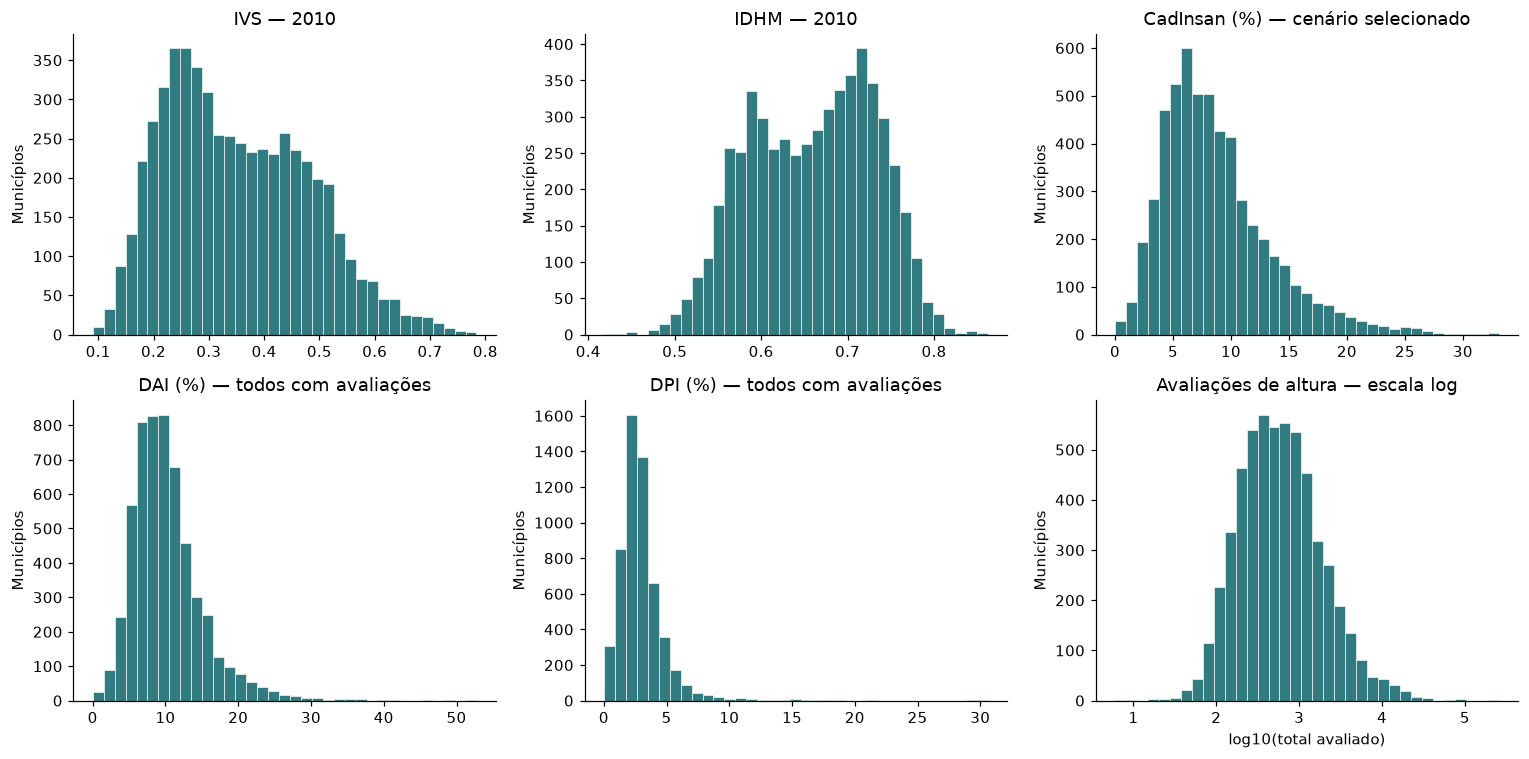

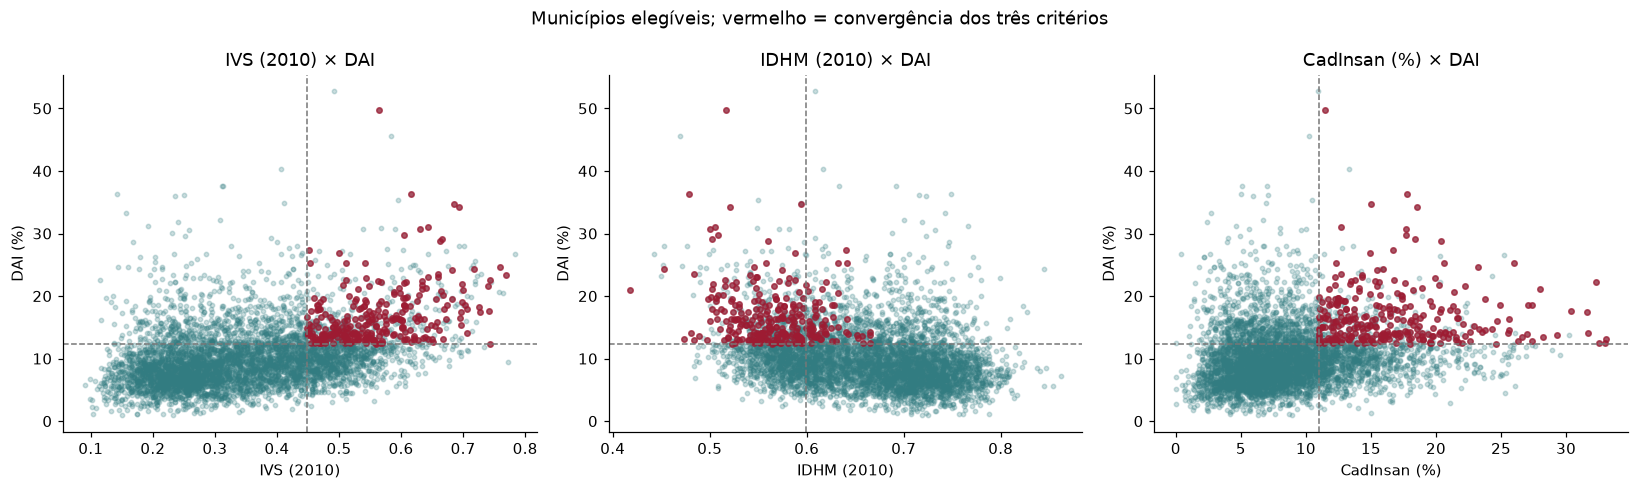

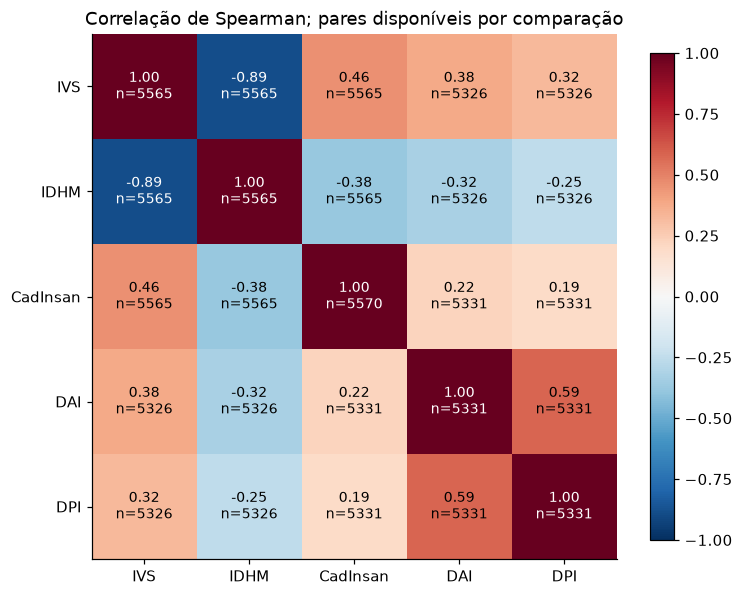

In [8]:
display(distribution_figure(classificados, PASTA_FIGURAS))
plt.close("all")
display(association_figure(classificados, cortes, PASTA_FIGURAS))
plt.close("all")
figura_correlacao, correlacoes, n_pares = correlation_figure(classificados, PASTA_FIGURAS, MINIMO_AVALIADOS)
display(figura_correlacao)
plt.close("all")

**Interpretação:** avaliar se valores desfavoráveis coincidem, a dispersão e
possíveis diferenças regionais. Correlações são descritivas: não demonstram
causalidade, relações individuais ou validação independente do CadInsan.
Este depende do CadÚnico; IVS e IDHM também podem conter informação redundante.
Não somamos os cinco indicadores em um índice.

## 7. Mapas nacionais e disponibilidade dos dados

A malha simplificada incorporada vem da **API v4 do IBGE**. Essa versão não
informa o ano por parâmetro; não a descrevemos como malha de 2025. A data,
URL e hash estão nos metadados. A geometria é apoio ilustrativo: os códigos
são auditados, mas isso não harmoniza limites históricos. Municípios sem
informações suficientes permanecem visíveis em cinza.

,fonte,url,obtido_em,sha256,feicoes,ano_malha,nota,documentacao
0,"IBGE, API de malhas simplificadas v4",https://servicodados.ibge.gov.br/api/v4/malhas...,2026-10-04T15:12:31.081960+00:00,5491bd548fe381cd388ba81c9edfbf4cf2749891e2fd32...,5571,None,API v4 não expõe parâmetro de período. Não afi...,https://servicodados.ibge.gov.br/api/docs/malh...


Municípios da base sem geometria: 0
Feições da malha sem registro na base: 0


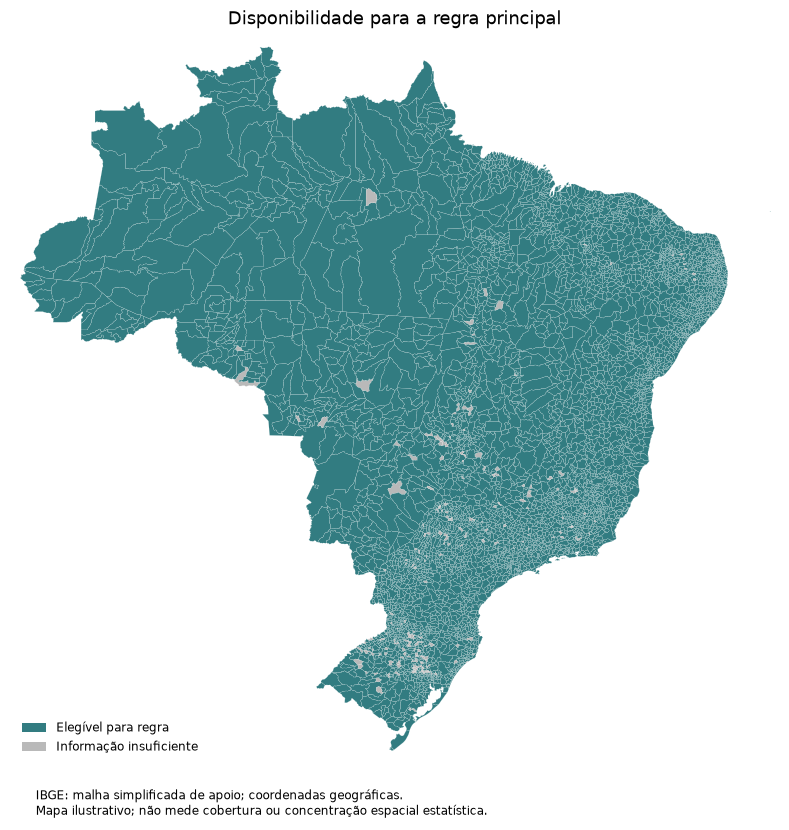

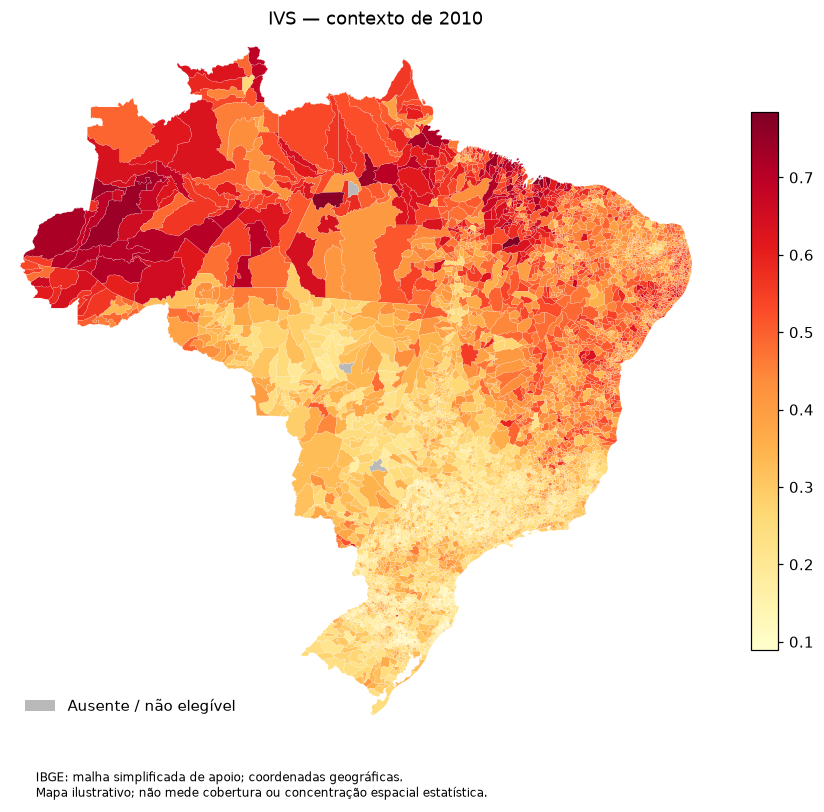

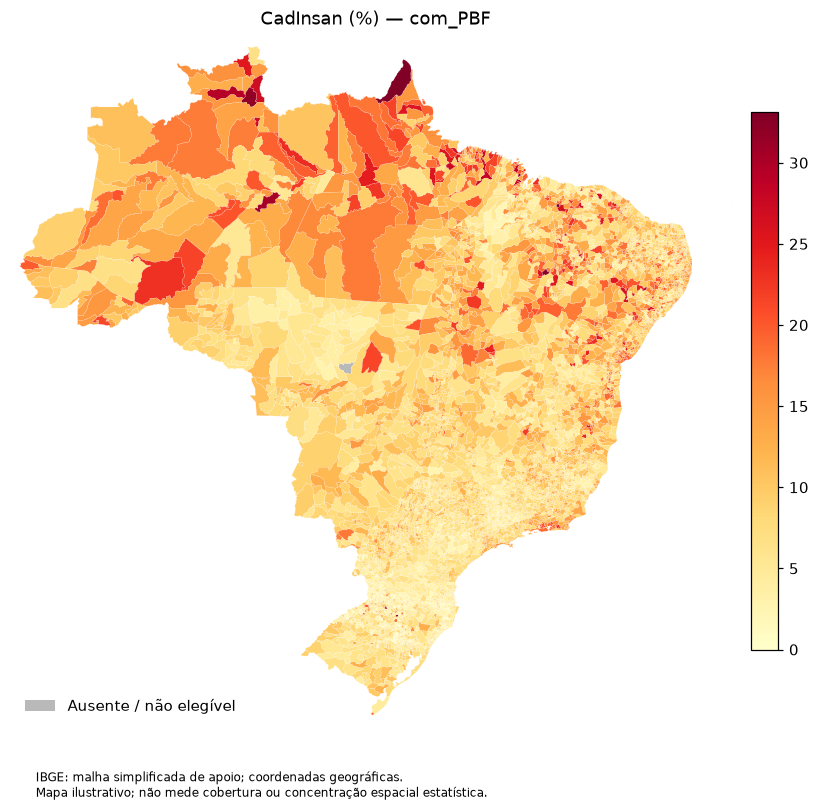

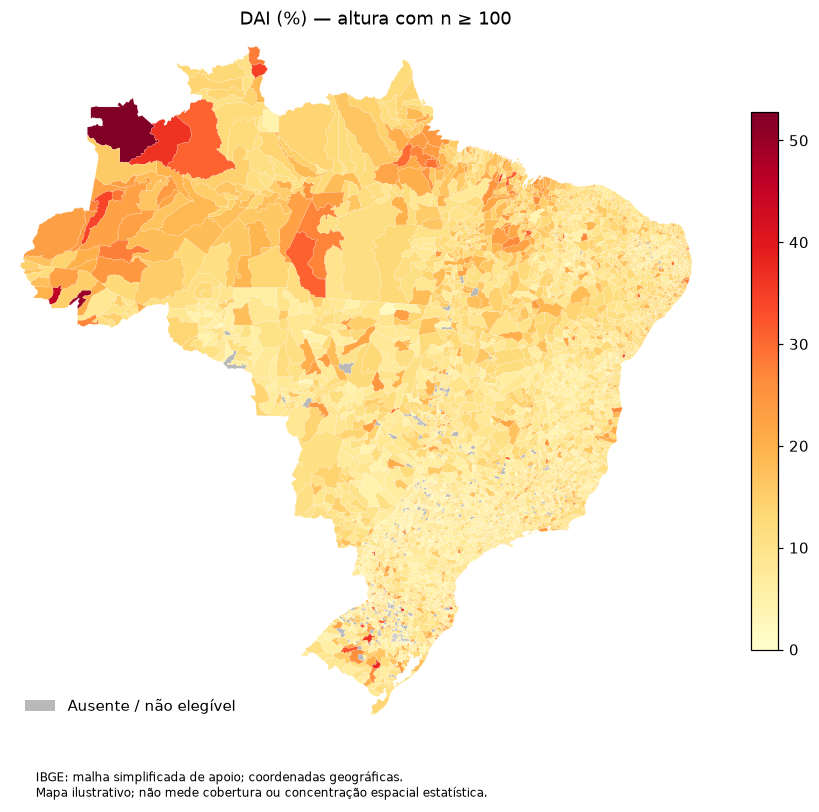

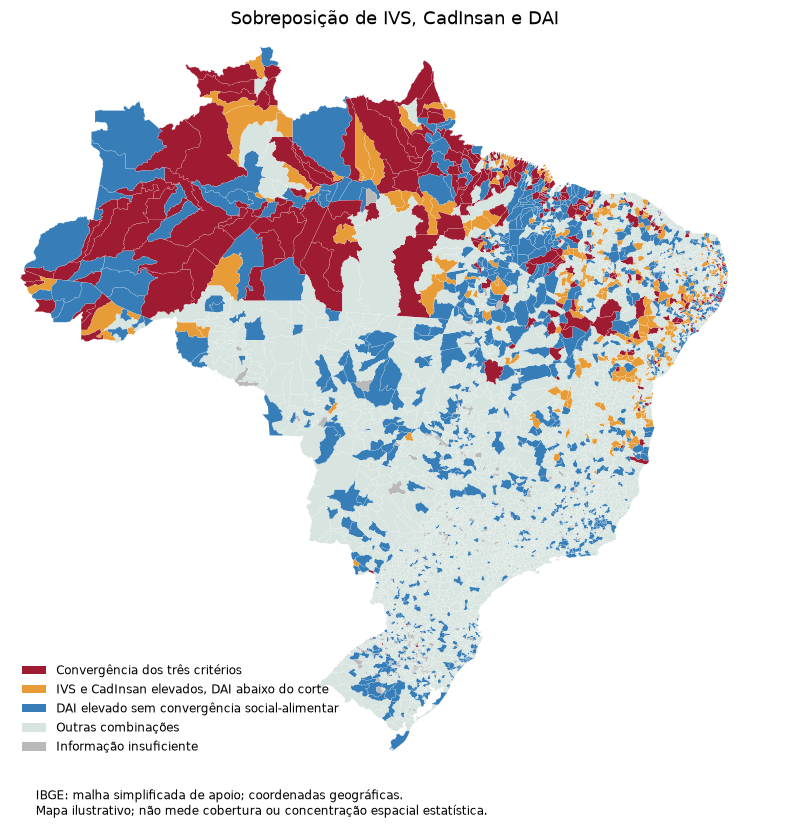

In [9]:
caminho_malha = PASTA_DADOS / "apoio/ibge/malha_municipal_simplificada.geojson"
metadados_malha = json.loads((PASTA_DADOS / "apoio/ibge/malha_municipal_simplificada.metadados.json").read_text())
if hashlib.sha256(caminho_malha.read_bytes()).hexdigest() != metadados_malha["sha256"]:
    raise ValueError("Hash da malha diferente do registrado")
geometria = json.loads(caminho_malha.read_text())
controle_geometria = geometry_audit(geometria, base)
display(pd.DataFrame([metadados_malha]))
print("Municípios da base sem geometria:", int((~controle_geometria["tem_geometria"]).sum()))
print("Feições da malha sem registro na base:",
      len({str(f["properties"]["codarea"])[:6] for f in geometria["features"]} - set(base["codigo_ibge_6"])))
if GERAR_MAPAS:
    mapa = classificados.copy()
    mapa["disponibilidade"] = mapa["elegivel_principal"].map({True: "Elegível para regra", False: "Informação insuficiente"})
    display(map_figure(geometria, mapa, "disponibilidade", "Disponibilidade para a regra principal", PASTA_FIGURAS,
                       "05_disponibilidade", {"Elegível para regra": "#327c81", "Informação insuficiente": "#b9b9b9"}))
    plt.close("all")
    for coluna, titulo, nome in [("ivs", "IVS — contexto de 2010", "06_ivs"),
                                ("cadinsan_pct", f"CadInsan (%) — {CENARIO_CADINSAN}", "07_cadinsan"),
                                ("dai_pct", f"DAI (%) — altura com n ≥ {MINIMO_AVALIADOS}", "08_dai")]:
        if coluna == "dai_pct":
            mapa[coluna] = mapa[coluna].where(mapa["avaliados_altura"] >= MINIMO_AVALIADOS)
        display(map_figure(geometria, mapa, coluna, titulo, PASTA_FIGURAS, nome))
        plt.close("all")
    display(map_figure(geometria, classificados, "perfil", "Sobreposição de IVS, CadInsan e DAI", PASTA_FIGURAS,
                       "09_sobreposicao", GROUP_COLORS))
    plt.close("all")

**Interpretação:** o mapa final identifica coincidência municipal dos
critérios. Áreas visualmente próximas não constituem teste de agrupamento
espacial. A área dos polígonos não representa população ou quantidade de
famílias. O mapa de disponibilidade não é mapa de cobertura populacional.

## 8. Municípios selecionados e comparação regional

A tabela exibe os municípios com convergência e os indicadores que justificam
sua seleção. Está ordenada por UF e município, **sem ranking composto**.
As regiões apresentam DAI/DPI pela razão entre somas de numeradores e
denominadores, usando todos os registros válidos do respectivo índice.

In [10]:
colunas_apresentacao = ["codigo_ibge_6", "codigo_ibge_7", "municipio", "uf", "ivs", "idhm",
                       "cadinsan_pct", "cadinsan_n", "dai_pct", "avaliados_altura",
                       "dpi_pct", "avaliados_peso", "cadunico_valor_original", "cadastros_cadunico_cadinsan",
                       "criterio_idhm", "criterio_dpi"]
prioritarios = classificados.loc[classificados["prioritario"].fillna(False)].sort_values(["uf", "municipio"])
print("Municípios com convergência:", len(prioritarios))
display(prioritarios[colunas_apresentacao].head(30))
print("Prévia dos primeiros 30; a tabela completa será exportada.")
resumo_regional = regional_summary(classificados)
display(resumo_regional)

Municípios com convergência: 275


,codigo_ibge_6,codigo_ibge_7,municipio,uf,ivs,idhm,cadinsan_pct,cadinsan_n,dai_pct,avaliados_altura,dpi_pct,avaliados_peso,cadunico_valor_original,cadastros_cadunico_cadinsan,criterio_idhm,criterio_dpi
53,120005,1200054,ASSIS BRASIL,AC,0.500,0.588,14.900,223.000,26.857,1158.000,2.677,1158.000,9486.000,1499.000,True,False
61,120033,1200336,MANCIO LIMA,AC,0.537,0.625,19.800,680.000,14.859,1171.000,4.184,1171.000,16758.000,3432.000,False,True
62,120034,1200344,MANOEL URBANO,AC,0.589,0.551,14.900,447.000,20.339,1239.000,8.394,1239.000,11655.000,3006.000,True,True
63,120035,1200351,MARECHAL THAUMATURGO,AC,0.610,0.501,11.000,265.000,19.789,1804.000,3.381,1804.000,16086.000,2410.000,True,False
67,120042,1200427,RODRIGUES ALVES,AC,0.553,0.567,13.600,410.000,16.371,959.000,5.631,959.000,12891.000,3013.000,True,True
68,120043,1200435,SANTA ROSA DO PURUS,AC,0.564,0.517,11.500,116.000,49.710,690.000,12.754,690.000,6324.000,1012.000,True,True
1654,270050,2700508,BARRA DE SANTO ANTONIO,AL,0.551,0.557,11.700,339.000,13.320,1036.000,5.212,1036.000,13057.000,2891.000,True,True
1659,270100,2701001,BOCA DA MATA,AL,0.497,0.604,17.100,652.000,13.440,1317.000,2.354,1317.000,15763.000,3812.000,False,False
1668,270180,2701803,CARNEIROS,AL,0.604,0.526,12.400,275.000,18.602,758.000,3.430,758.000,8010.000,2210.000,True,False
1671,270210,2702108,COLONIA LEOPOLDINA,AL,0.548,0.517,12.300,507.000,15.965,1021.000,4.212,1021.000,13508.000,4133.000,True,True


Prévia dos primeiros 30; a tabela completa será exportada.


,regiao,municipios,elegiveis,prioritarios,pct_prioritarios_entre_elegiveis,dai_n,avaliados_altura,dai_pct_agregado,dpi_n,avaliados_peso,dpi_pct_agregado
0,Centro-Oeste,468,440,1,0.227,67995.000,631574.000,10.766,21082.000,631571.000,3.338
1,Nordeste,1794,1784,156,8.744,297697.000,2568298.000,11.591,89064.000,2568343.000,3.468
2,Norte,450,441,114,25.850,148137.000,1022788.000,14.484,42435.000,1022793.000,4.149
3,Sudeste,1668,1596,1,0.063,268290.000,2600965.000,10.315,87098.000,2600886.000,3.349
4,Sul,1191,1065,3,0.282,95589.000,1022788.000,9.346,26962.000,1022793.000,2.636


## 9. Sensibilidade e estabilidade da seleção

Cada cenário recalcula os cortes nacionais, inclusive o corte do DAI sobre
municípios com o mínimo escolhido. Portanto a comparação avalia tanto a
mudança de elegibilidade quanto a mudança da referência do corte. O Jaccard
compara a interseção das listas com sua união, em relação à regra principal.

A frequência de seleção é a fração das especificações testadas, **não uma
probabilidade de risco ou medida de incerteza amostral**. Os cenários CadInsan
têm interpretações distintas e são discriminados na tabela.

,cenario,quantil,minimo_avaliados,elegiveis,prioritarios,coincidentes_principal,jaccard_principal
0,com_PBF,0.750,30,5555,277,275,0.993
1,com_PBF,0.750,50,5531,277,275,0.993
2,com_PBF,0.750,100,5326,275,275,1.000
3,com_PBF,0.800,30,5555,182,182,0.662
4,com_PBF,0.800,50,5531,182,182,0.662
5,com_PBF,0.800,100,5326,182,182,0.662
6,sem_PBF,0.750,30,5555,320,187,0.458
7,sem_PBF,0.750,50,5531,320,187,0.458
8,sem_PBF,0.750,100,5326,319,187,0.459
9,sem_PBF,0.800,30,5555,202,130,0.375


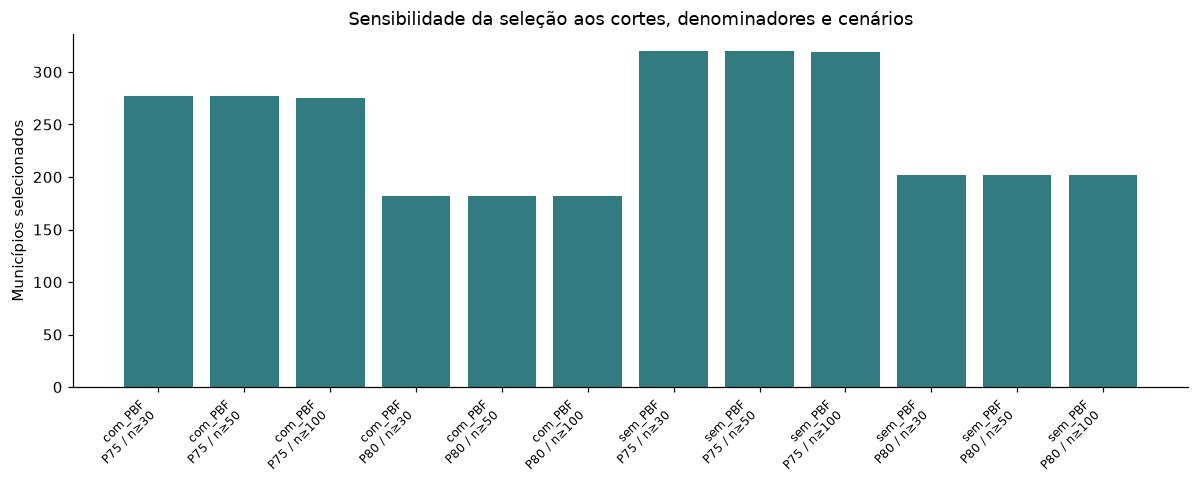

,municipio,uf,cenarios_elegiveis,cenarios_selecionado,cenarios_testados,fracao_cenarios_selecionado
53,ASSIS BRASIL,AC,12,12,12,1.000
61,MANCIO LIMA,AC,12,12,12,1.000
62,MANOEL URBANO,AC,12,12,12,1.000
63,MARECHAL THAUMATURGO,AC,12,9,12,0.750
67,RODRIGUES ALVES,AC,12,12,12,1.000
68,SANTA ROSA DO PURUS,AC,12,3,12,0.250
1654,BARRA DE SANTO ANTONIO,AL,12,3,12,0.250
1659,BOCA DA MATA,AL,12,6,12,0.500
1668,CARNEIROS,AL,12,9,12,0.750
1671,COLONIA LEOPOLDINA,AL,12,6,12,0.500


In [11]:
quantis_teste = sorted(set(QUANTIS_SENSIBILIDADE + [QUANTIL]))
minimos_teste = sorted(set(MINIMOS_SENSIBILIDADE + [MINIMO_AVALIADOS]))
cenarios_teste = sorted(set(CENARIOS_SENSIBILIDADE + [CENARIO_CADINSAN]))
tabela_sensibilidade, estabilidade = sensitivity(base, classificados, quantis_teste, minimos_teste, cenarios_teste)
classificados = classificados.merge(estabilidade, on="codigo_ibge_6", validate="one_to_one")
prioritarios = classificados.loc[classificados["prioritario"].fillna(False)].sort_values(["uf", "municipio"])
display(tabela_sensibilidade)
display(sensitivity_figure(tabela_sensibilidade, PASTA_FIGURAS))
plt.close("all")
display(prioritarios[["municipio", "uf", "cenarios_elegiveis", "cenarios_selecionado",
                      "cenarios_testados", "fracao_cenarios_selecionado"]].head(30))

## 10. Síntese para o laboratório e limitações

A síntese abaixo é preenchida com os resultados da execução. Antes de usar
como conclusão definitiva, conferir as pendências metodológicas das fontes.

In [12]:
elegiveis = int(classificados["elegivel_principal"].sum())
selecionados = len(prioritarios)
resumo_execucao = f"""# Síntese exploratória\n\nForam preservados {len(base):,} municípios na união das fontes; \
{elegiveis:,} são elegíveis para a regra principal e {selecionados:,} apresentam convergência de IVS, \
CadInsan e DAI elevados ({selecionados / elegiveis * 100 if elegiveis else 0:.2f}% dos elegíveis).\n\n\
Parâmetros: percentil {QUANTIL * 100:.0f}, cenário `{CENARIO_CADINSAN}`, mínimo de \
{MINIMO_AVALIADOS} avaliações de altura. Os cortes são relativos e não classificações oficiais.\n\n\
A seleção variou de {tabela_sensibilidade.prioritarios.min()} a \
{tabela_sensibilidade.prioritarios.max()} municípios nas especificações testadas. \
Consultar a tabela de sensibilidade para distinguir cenários, cortes e denominadores.\n\n\
**Limitações:** IVS/IDHM de 2010; SISVAN e arquivo CadInsan de 2025; SISVAN representa \
a população acompanhada; nenhum indicador de cobertura populacional foi calculado; \
CadÚnico JSON tem unidade/período pendentes; definições específicas do arquivo CadInsan \
precisam de confirmação; malha ilustrativa sem ano identificado pela API; associação \
municipal não demonstra causalidade nem relações individuais.\n"""
display(Markdown(resumo_execucao))

# Síntese exploratória

Foram preservados 5,571 municípios na união das fontes; 5,326 são elegíveis para a regra principal e 275 apresentam convergência de IVS, CadInsan e DAI elevados (5.16% dos elegíveis).

Parâmetros: percentil 75, cenário `com_PBF`, mínimo de 100 avaliações de altura. Os cortes são relativos e não classificações oficiais.

A seleção variou de 182 a 320 municípios nas especificações testadas. Consultar a tabela de sensibilidade para distinguir cenários, cortes e denominadores.

**Limitações:** IVS/IDHM de 2010; SISVAN e arquivo CadInsan de 2025; SISVAN representa a população acompanhada; nenhum indicador de cobertura populacional foi calculado; CadÚnico JSON tem unidade/período pendentes; definições específicas do arquivo CadInsan precisam de confirmação; malha ilustrativa sem ano identificado pela API; associação municipal não demonstra causalidade nem relações individuais.


## 11. Exportação e reprodução

Exportamos a base derivada, lista completa de municípios com convergência,
cortes, controles de qualidade, sensibilidade, dicionário, resumo e figuras
PNG/SVG. Os CSVs usam UTF-8 com BOM. O manifesto registra parâmetros, hashes e
versões efetivamente utilizadas. A execução não modifica as quatro bases.

Cada execução recebe uma pasta própria, evitando mistura de figuras de
configurações distintas. Um ZIP reúne resultados e documentação das entradas.
Para baixar no Colab, ativar `BAIXAR_RESULTADOS_NO_COLAB` no início ou usar
a aba de arquivos. A exportação não inclui dados pessoais individuais.

In [13]:
identificador = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
destino = PASTA_SAIDA / f"execucao_{identificador}"
destino.mkdir()
tabelas = {"base_analitica": classificados, "municipios_prioritarios": prioritarios,
           "cortes": cortes, "controle_integracao": controle_integracao,
           "municipios_sem_correspondencia": ausencias, "sem_classificacao": sem_classificacao,
           "qualidade_sisvan": qualidade_sisvan, "controle_geometria": controle_geometria,
           "resumo_regional": resumo_regional, "sensibilidade": tabela_sensibilidade,
           "estabilidade": estabilidade, "dicionario_variaveis": dictionary(),
           "correlacoes_spearman": correlacoes.rename_axis("indicador").reset_index(),
           "n_pares_correlacao": n_pares.rename_axis("indicador").reset_index()}
for nome, tabela in tabelas.items():
    tabela.to_csv(destino / f"{nome}.csv", index=False, encoding="utf-8-sig")
figuras_desta_execucao = ["01_distribuicoes", "02_associacoes", "03_correlacoes", "04_sensibilidade"]
if GERAR_MAPAS:
    figuras_desta_execucao += ["05_disponibilidade", "06_ivs", "07_cadinsan", "08_dai", "09_sobreposicao"]
(destino / "figuras").mkdir()
for nome in figuras_desta_execucao:
    for extensao in ["png", "svg"]:
        shutil.copy2(PASTA_FIGURAS / f"{nome}.{extensao}", destino / "figuras")
ambiente = {"python": platform.python_version(), "pandas": pd.__version__, "numpy": np.__version__,
            "matplotlib": matplotlib.__version__, "scipy": scipy.__version__}
manifesto = {"executado_em": datetime.now(timezone.utc).isoformat(),
             "versao_bases": "3391236", "quantil": QUANTIL, "minimo_avaliados": MINIMO_AVALIADOS,
             "cenario_cadinsan": CENARIO_CADINSAN, "cortes": cortes.to_dict("records"),
             "definicoes_cadinsan_confirmadas": DEFINICOES_CADINSAN_CONFIRMADAS,
             "cadunico_unidade_confirmada": CADUNICO_UNIDADE_CONFIRMADA,
             "cadunico_periodo_confirmado": CADUNICO_PERIODO_CONFIRMADO,
             "sensibilidade": tabela_sensibilidade.to_dict("records"), "ambiente": ambiente,
             "hashes_entrada": hashes_entrada.to_dict("records"), "malha": metadados_malha,
             "codigo_analise_sha256": CODIGO_ANALISE_SHA256,
             "regra": "IVS >= corte e CadInsan >= corte e DAI >= corte; denominadores válidos",
             "limites": ["Estudo ecológico exploratório", "Sem inferência causal",
                         "Sem cobertura populacional calculada", "Referências temporais distintas",
                         "Cenários CadInsan e unidade/período CadÚnico precisam de confirmação"]}
(destino / "manifesto_execucao.json").write_text(json.dumps(manifesto, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
(destino / "resumo.md").write_text(resumo_execucao, encoding="utf-8")
shutil.copytree(PASTA_DADOS / "documentacao", destino / "documentacao_entradas")
shutil.copy2(PASTA_DADOS / "README.md", destino / "documentacao_entradas/README_SELECAO.md")
shutil.copy2(PASTA_DADOS / "SHA256SUMS", destino / "documentacao_entradas")
arquivo_zip = shutil.make_archive(str(destino), "zip", root_dir=destino)
print("ZIP pronto:", arquivo_zip)
display(pd.DataFrame([ambiente]))
if BAIXAR_RESULTADOS_NO_COLAB:
    try:
        from google.colab import files
    except ImportError:
        print("Fora do Colab: utilizar o ZIP no caminho informado.")
    else:
        files.download(arquivo_zip)

ZIP pronto: /tmp/risco-notebook-execucao-diyd4nhx/resultados_sobreposicao/resultados/execucao_20261004T151658225292Z.zip


,python,pandas,numpy,matplotlib,scipy
0,3.13.12,3.0.5,2.5.3,3.11.2,1.18.1


## Referências e documentação

- [CadInsan — MDS](https://www.gov.br/mds/pt-br/Sisan/monitoramento-da-san/cadinsan).
- [Relatório metodológico CadInsan](https://www.gov.br/mds/pt-br/caisan/monitoramento-da-san/Relatorio_CadINSAN.pdf).
- [SISVAN — Ministério da Saúde](https://www.gov.br/saude/pt-br/composicao/saps/vigilancia-alimentar-e-nutricional/sisvan).
- [IVS e IDHM — Ipea](https://repositorio.ipea.gov.br/bitstream/11058/8257/2/vulnerability.pdf).
- [API de malhas simplificadas v4 — IBGE](https://servicodados.ibge.gov.br/api/docs/malhas?versao=4).
- No projeto: `docs/metodologia/PLANO_ANALISE_NOTEBOOK_COLAB.md`,
  `dados/pesquisa/README.md`, `scripts/analise_sobreposicao.py` e
  `scripts/gerar_notebook_sobreposicao.py`.

Pendências permanecem visíveis mesmo quando o código termina sem erros:
qualidade computacional não substitui a confirmação metodológica das fontes.